In [10]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iterate
importlib.reload(iterate)
from iterate import iterate, h

np.set_printoptions(suppress=True)

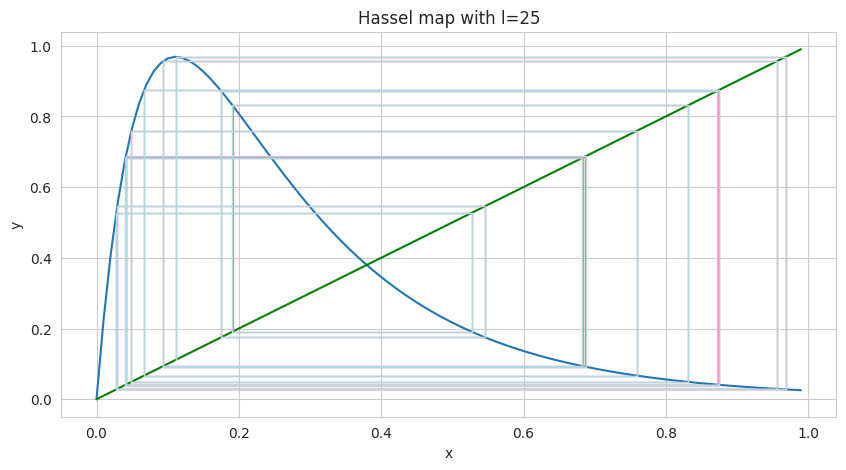

In [74]:
def plt_map(l, xmin=0, xmax=1, xstep=0.01):
    xs = np.arange(xmin, xmax, xstep)
    ys = [h(l, x) for x in xs]
    plt.figure(figsize=(10, 5), dpi=100)
    sns.set_style("whitegrid")
    sns.lineplot(x=xs, y=ys)
    sns.lineplot(x=xs, y=xs, color="green")
    plt.title(f"Hassel map with l={l}")
    plt.xlabel("x")
    plt.ylabel("y")

def plt_cobweb(l, x0, n=50, color='lightcoral', lw=1):
    visits = iterate(l, x0, n)[1]

    # Cobweb diagram - starts at (x0, x0), goes to (x0, h(l, x0)), then to (h(l, x0), h(l, x0)), etc

    plt.plot([x0, x0], [x0, h(l, x0)], color=color, lw=lw)
    plt.plot([x0, h(l, x0)], [h(l, x0), h(l, x0)], color=color, lw=lw)

    for i in range(len(visits) - 1):
        plt.plot([visits[i], visits[i]], [visits[i], visits[i + 1]], color=color, lw=lw)
        plt.plot([visits[i], visits[i + 1]], [visits[i + 1], visits[i + 1]], color=color, lw=lw)

plt_map(l=25, xmin=0, xmax=1, xstep=0.01)
plt_cobweb(l=25, x0=1/9, n=20)
plt_cobweb(l=25, x0=1/9+0.001, n=20, color='lightblue')
plt.show()

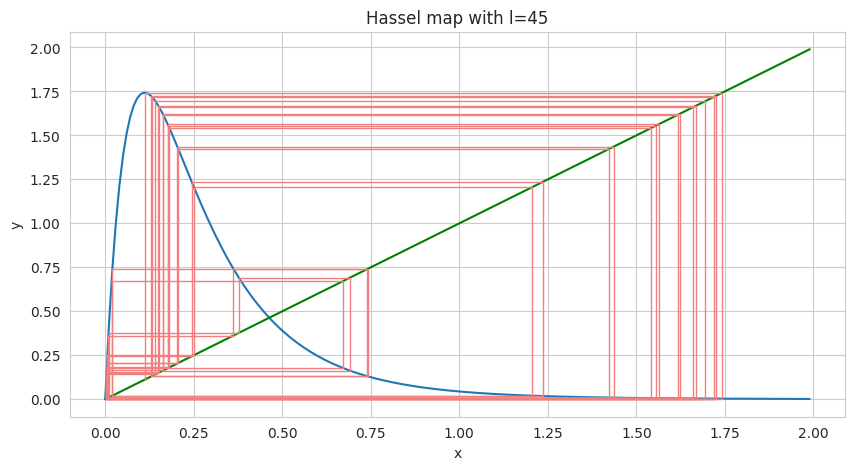

In [76]:
plt_map(l=45, xmin=0, xmax=2, xstep=0.01)
plt_cobweb(l=45, x0=1/9, n=50)
plt.show()

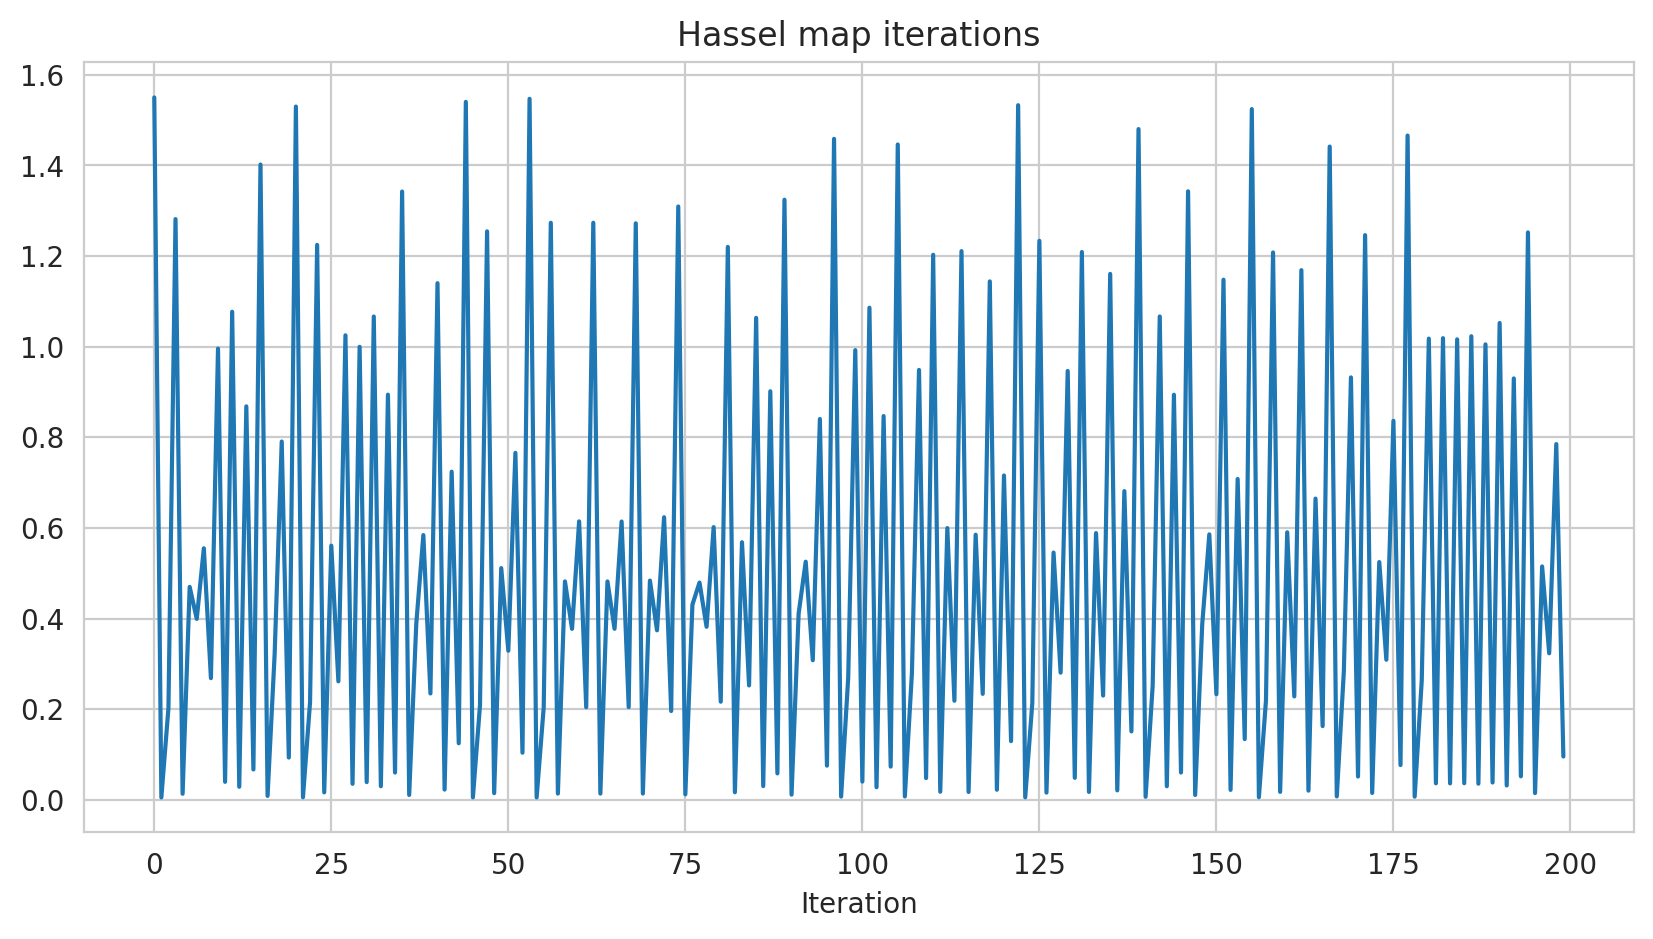

In [73]:
l = 40
visits_1 = iterate(l=l, x0=1/9, lim=200)[1]
visits_2 = iterate(l=l, x0=1/9+0.0001, lim=200)[1]
err = np.array(visits_1) - np.array(visits_2)

plt.figure(figsize=(10, 5), dpi=200)
sns.set_style("whitegrid")
sns.lineplot(x=range(len(visits_1)), y=visits_1)
plt.title("Hassel map iterations")
plt.xlabel("Iteration")
plt.show()